## 1) Load Dataset


In [1]:

import pandas as pd
import numpy as np


DATA_PATH = "Bangladesh-Crime-Dataset.csv" # Define the dataset file path


df = pd.read_csv(DATA_PATH) # Load the dataset into a pandas DataFrame


print("Original shape of dataset:", df.shape) # Display the initial shape of the dataset


display(df.head())  # Show the first 5 rows to understand the structure of the data

# Remove the unnecessary index-like column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])


print("Shape after dropping 'Unnamed: 0':", df.shape)# Display the shape after removing the unnecessary column

Original shape of dataset: (6574, 38)


,Unnamed: 0,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,latitude,longitude,incident_place,incident_district,...,literacy_rate,religious_institution,playground,park,police_station,cyber_cafe,school,college,cinema,crime
0,0,7,29,wednesday,0,morning,23.774569,90.355292,adabar,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
1,1,1,2,wednesday,0,night,23.774569,90.355292,adabar,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
2,2,1,4,tuesday,0,night,23.769808,90.351595,adabor,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
3,3,3,9,friday,1,night,23.728907,90.417137,aftabnagar,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder
4,4,8,34,thursday,0,night,23.847177,90.404133,airport,dhaka,...,74.6,4289,99,17,60,478,242,64,40,murder


Shape after dropping 'Unnamed: 0': (6574, 37)


In [2]:

target = "crime" # Define the target column for the classification problem
print("Total missing values in the dataset:", df.isna().sum().sum()) # Check the total number of missing values in the dataset
# Display the distribution of the target classes
print("\nClass distribution of the target variable:")
print(df[target].value_counts())

Total missing values in the dataset: 0

Class distribution of the target variable:
crime
murder       1518
bodyfound    1517
rape         1193
assault      1097
kidnap        651
robbery       598
Name: count, dtype: int64


## 2) EDA — Class Distribution



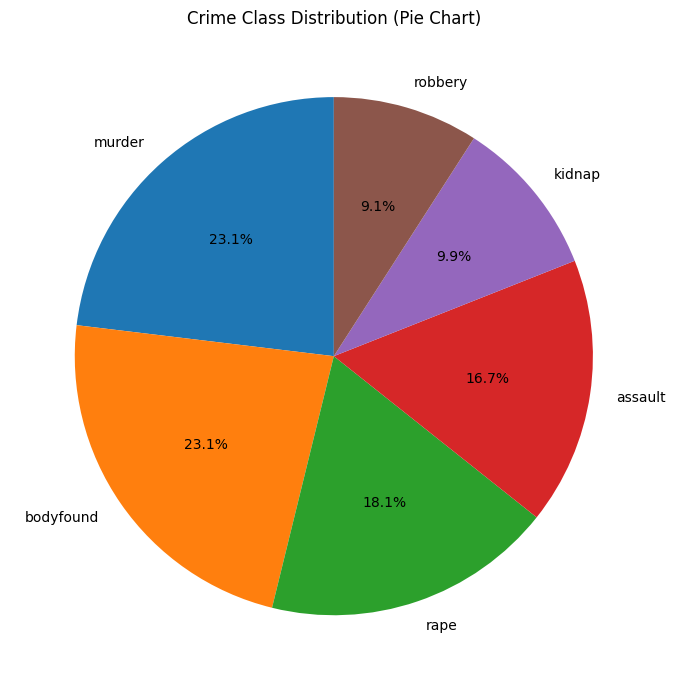

In [3]:

import matplotlib.pyplot as plt # Import matplotlib for data visualization

counts = df[target].value_counts() # Count the number of samples in each crime class

# Create a pie chart to visualize the percentage distribution of crime classes
plt.figure(figsize=(7, 7))
plt.pie(
    counts.values,                  # class frequencies
    labels=counts.index.astype(str),# class labels
    autopct="%1.1f%%",              # show percentages on the chart
    startangle=90                   # rotate chart for better appearance
)

# Add title to the chart
plt.title("Crime Class Distribution (Pie Chart)")

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

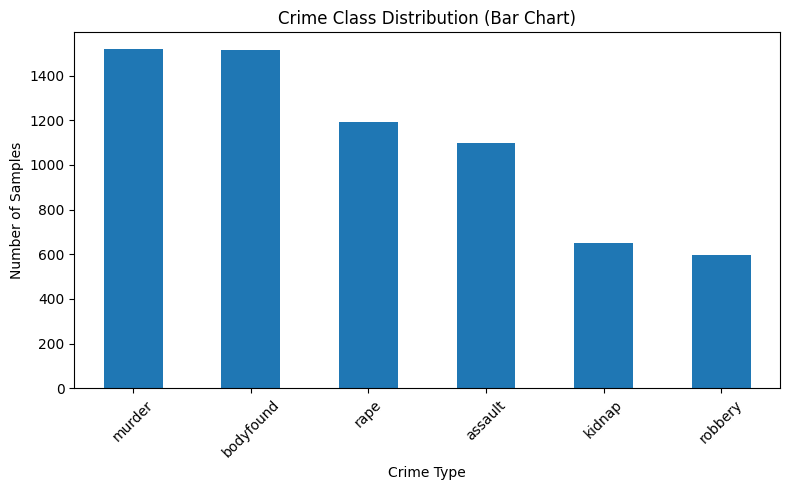

In [4]:

import matplotlib.pyplot as plt # Import matplotlib for visualization

counts = df[target].value_counts() 

# Create a bar chart to compare the frequency of each crime class
plt.figure(figsize=(8, 5))
counts.plot(kind="bar")

# Add title and axis labels
plt.title("Crime Class Distribution (Bar Chart)")
plt.xlabel("Crime Type")
plt.ylabel("Number of Samples")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

## 3) Split Features (X) and Target (y)

In [5]:
# Import required modules for data splitting and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Separate input features (X) and target variable (y)
X = df.drop(columns=[target])
y = df[target]

# Define categorical columns that need encoding
cat_cols = [
    "incident_weekday",
    "weekend",
    "part_of_the_day",
    "incident_place",
    "incident_district",
    "incident_division",
    "season",
    "weather_code"  # treated as a categorical weather indicator
]

# Define numerical columns automatically by excluding categorical columns
num_cols = [col for col in X.columns if col not in cat_cols]

# Display the selected categorical and numerical columns
print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['incident_weekday', 'weekend', 'part_of_the_day', 'incident_place', 'incident_district', 'incident_division', 'season', 'weather_code']
Numerical columns: ['incident_month', 'incident_week', 'latitude', 'longitude', 'max_temp', 'avg_temp', 'min_temp', 'precip', 'humidity', 'visibility', 'cloudcover', 'heatindex', 'household', 'male_population', 'female_population', 'total_population', 'gender_ration', 'average_household_size', 'density_per_kmsq', 'literacy_rate', 'religious_institution', 'playground', 'park', 'police_station', 'cyber_cafe', 'school', 'college', 'cinema']


## 4) Train/Test Split (80/20, Stratified)


In [6]:
# Create a preprocessing pipeline for categorical and numerical features
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),  # encode categorical features
        ("num", StandardScaler(), num_cols),                        # scale numerical features
    ],
    remainder="drop"  # ignore any remaining columns not listed above
)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # use 80% data for training and 20% for testing
    random_state=42,    # ensures reproducibility
    stratify=y          # preserves class distribution in both sets
)

# Display the shape of the training and testing data
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (5259, 36)
Testing set shape: (1315, 36)
